# Long Short Term Memory Networks for IoT Prediction

RNNs and LSTM models are very popular neural network architectures when working with sequential data, since they both carry some "memory" of previous inputs when predicting the next output. In this assignment we will continue to work with the Household Electricity Consumption dataset and use an LSTM model to predict the Global Active Power (GAP) from a sequence of previous GAP readings. You will build one model following the directions in this notebook closely, then you will be asked to make changes to that original model and analyze the effects that they had on the model performance. You will also be asked to compare the performance of your LSTM model to the linear regression predictor that you built in last week's assignment.

## General Assignment Instructions

These instructions are included in every assignment, to remind you of the coding standards for the class. Feel free to delete this cell after reading it. 

One sign of mature code is conforming to a style guide. We recommend the [Google Python Style Guide](https://google.github.io/styleguide/pyguide.html). If you use a different style guide, please include a cell with a link. 

Your code should be relatively easy-to-read, sensibly commented, and clean. Writing code is a messy process, so please be sure to edit your final submission. Remove any cells that are not needed or parts of cells that contain unnecessary code. Remove inessential `import` statements and make sure that all such statements are moved into the designated cell. 

When you save your notebook as a pdf, make sure that all cell output is visible (even error messages) as this will aid your instructor in grading your work.

Make use of non-code cells for written commentary. These cells should be grammatical and clearly written. In some of these cells you will have questions to answer. The questions will be marked by a "Q:" and will have a corresponding "A:" spot for you. *Make sure to answer every question marked with a `Q:` for full credit.* 

In [25]:
import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Setting seed for reproducibility
np.random.seed(1234)  
PYTHONHASHSEED = 0

from sklearn import preprocessing
from sklearn.metrics import confusion_matrix, recall_score, precision_score
from sklearn.model_selection import train_test_split
from keras.models import Sequential,load_model
from keras.layers import Dense, Dropout, LSTM
from keras.layers.core import Activation
from keras.utils import pad_sequences

In [26]:
#use this cell to import additional libraries or define helper functions

## Load and prepare your data

We'll once again be using the cleaned household electricity consumption data from the previous two assignments. I recommend saving your dataset by running df.to_csv("filename") at the end of assignment 2 so that you don't have to re-do your cleaning steps. If you are not confident in your own cleaning steps, you may ask your instructor for a cleaned version of the data. You will not be graded on the cleaning steps in this assignment, but some functions may not work if you use the raw data.

Unlike when using Linear Regression to make our predictions for Global Active Power (GAP), LSTM requires that we have a pre-trained model when our predictive software is shipped (the ability to iterate on the model after it's put into production is another question for another day). Thus, we will train the model on a segment of our data and then measure its performance on simulated streaming data another segment of the data. Our dataset is very large, so for speed's sake, we will limit ourselves to 1% of the entire dataset.

**TODO: Import your data, select the a random 1% of the dataset, and then split it 80/20 into training and validation sets (the test split will come from the training data as part of the tensorflow LSTM model call). HINT: Think carefully about how you do your train/validation split--does it make sense to randomize the data?**

In [27]:
#Load your data into a pandas dataframe here
# Load your data into a pandas dataframe here
df = pd.read_csv("household_power_clean.csv")

# Select random 1% of data
df_sample = df.sample(frac=0.01, random_state=123)


# Split into training and validation sets
train_df, val_df = train_test_split(df_sample, test_size=0.2, shuffle=False, random_state=123)


In [28]:
#create your training and validation sets here

#assign size for data subset
subset_size = int(len(df) * 0.01)

#take random data subset
subset = df.sample(n=subset_size, random_state=123)

#split data subset 80/20 for train/validation
train_df, val_df = train_test_split(subset, test_size=0.2, random_state=123)



In [29]:
#reset the indices for cleanliness
train_df = train_df.reset_index()
val_df = val_df.reset_index()

Next we need to create our input and output sequences. In the lab session this week, we used an LSTM model to make a binary prediction, but LSTM models are very flexible in what they can output: we can also use them to predict a single real-numbered output (we can even use them to predict a sequence of outputs). Here we will train a model to predict a single real-numbered output such that we can compare our model directly to the linear regression model from last week.

**TODO: Create a nested list structure for the training data, with a sequence of GAP measurements as the input and the GAP measurement at your predictive horizon as your expected output**

In [31]:
train_df

,index,Unnamed: 0,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime,gap_monthly,grp_monthly,v_monthly,gi_monthly
0,712038,715978,2008-04-26,22:22:00,0.548,0.000,243.10,2.2,0.0,0.0,1.0,2008-04-26 22:22:00,0.811933,0.072200,240.550000,3.346667
1,1832105,1845618,2010-06-20,09:42:00,1.698,0.210,239.44,7.2,0.0,1.0,19.0,2010-06-20 09:42:00,0.841067,0.088000,240.774000,3.606667
2,1102687,1106758,2009-01-23,07:22:00,2.328,0.000,236.93,9.8,0.0,0.0,17.0,2009-01-23 07:22:00,2.132533,0.054333,240.242333,8.846667
3,784049,787992,2008-06-15,22:36:00,0.712,0.242,241.60,3.0,0.0,0.0,0.0,2008-06-15 22:36:00,0.915133,0.130133,240.101000,3.913333
4,1184921,1189058,2009-03-21,11:02:00,1.286,0.000,241.21,5.2,0.0,0.0,18.0,2009-03-21 11:02:00,1.358400,0.062933,242.498667,5.533333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16388,545839,549774,2008-01-02,12:18:00,1.414,0.070,240.14,5.8,0.0,0.0,18.0,2008-01-02 12:18:00,1.363200,0.019600,240.398333,5.673333
16389,842881,846826,2008-07-26,19:10:00,0.168,0.000,242.52,0.8,0.0,0.0,1.0,2008-07-26 19:10:00,0.427533,0.240333,241.646333,2.066667
16390,1476237,1484584,2009-10-12,16:28:00,0.392,0.196,242.29,1.8,0.0,0.0,1.0,2009-10-12 16:28:00,0.276333,0.046267,242.324000,1.100000
16391,2039387,2065366,2010-11-20,00:10:00,0.396,0.232,247.01,1.8,0.0,1.0,0.0,2010-11-20 00:10:00,0.358400,0.164800,245.723667,1.540000


In [32]:
sequence_length = 10
seq_arrays = []
seq_labs = []

# create input sequences and corresponding labels
for i in range(len(train_df) - sequence_length):
    sequence = train_df['Global_active_power'].values[i:i+sequence_length]
    label = train_df['Global_active_power'].values[i+sequence_length]
    seq_arrays.append(sequence)
    seq_labs.append(label)

# convert lists to numpy arrays
seq_arrays = np.array(seq_arrays)
seq_labs = np.array(seq_labs)

# reshape input sequences to be 3D arrays
seq_arrays = np.reshape(seq_arrays, (seq_arrays.shape[0], sequence_length, 1))


In [58]:
# we'll start out with a 30 minute input sequence and a 5 minute predictive horizon
# we don't need to work in seconds this time, since we'll just use the indices instead of a unix timestamp
seq_length = 50
ph = 7

feat_cols = ['Global_active_power']

#create list of sequence length GAP readings
seq_arrays = []
seq_labs = []

for i in range(len(train_df) - seq_length - ph):
    sequence = train_df[feat_cols].values[i:i+seq_length]
    label = train_df['Global_active_power'].values[i+seq_length+ph]
    seq_arrays.append(sequence)
    seq_labs.append(label)

#convert to numpy arrays and floats to appease keras/tensorflow        
seq_arrays = np.array(seq_arrays, dtype = object).astype(np.float32)
seq_labs = np.array(seq_labs, dtype = object).astype(np.float32)

In [59]:
assert(seq_arrays.shape == (len(train_df)-seq_length-ph,seq_length, len(feat_cols)))
assert(seq_labs.shape == (len(train_df)-seq_length-ph,))

In [60]:
seq_arrays.shape

(16336, 50, 1)

**Q: What is the function of the assert statements in the above cell? Why do we use assertions in our code?**

A: The assert statements in the above cell are used to check if certain conditions are true. In this case, we use them to ensure that our seq_arrays and seq_labs arrays have the correct shape.

We use assertions in our code to make sure that certain conditions that we expect to be true are indeed true. If an assertion fails, it means that something unexpected has happened and that the code is not working as we intended. Using assertions can help catch errors and bugs earlier in the development process and make debugging easier.

## Model Training

We will begin with a model architecture very similar to the model we built in the lab session. We will have two LSTM layers, with 5 and 3 hidden units respectively, and we will apply dropout after each LSTM layer. However, we will use a LINEAR final layer and MSE for our loss function, since our output is continuous instead of binary.

**TODO: Fill in all values marked with a ?? in the cell below**

In [45]:
# define path to save model
model_path = 'LSTM_model1.h5'

# build the network
nb_features = 1
nb_out = 1

model = Sequential()

#add first LSTM layer
model.add(LSTM(
         input_shape=(seq_length, nb_features),
         units=5, 
         return_sequences=True))
model.add(Dropout(0.2)) 

# add second LSTM layer
model.add(LSTM(
          units=3,
          return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=nb_out))
model.add(Activation('linear'))
optimizer = keras.optimizers.Adam(learning_rate = 0.01)
model.compile(loss='mean_squared_error', optimizer=optimizer,metrics=['mse'])
print(model.summary())

# fit the network
history = model.fit(seq_arrays, seq_labs, epochs=100, batch_size=500, validation_split=0.05, verbose=2,
          callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=10, verbose=0, mode='min'),
                       keras.callbacks.ModelCheckpoint(model_path,monitor='val_loss', save_best_only=True, mode='min', verbose=0)]
          )

# list all data in history
print(history.history.keys())


Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_8 (LSTM)               (None, 30, 5)             140       
                                                                 
 dropout_8 (Dropout)         (None, 30, 5)             0         
                                                                 
 lstm_9 (LSTM)               (None, 3)                 108       
                                                                 
 dropout_9 (Dropout)         (None, 3)                 0         
                                                                 
 dense_4 (Dense)             (None, 1)                 4         
                                                                 
 activation_4 (Activation)   (None, 1)                 0         
                                                                 
Total params: 252
Trainable params: 252
Non-trainable 

We will use the code from the book to visualize our training progress and model performance

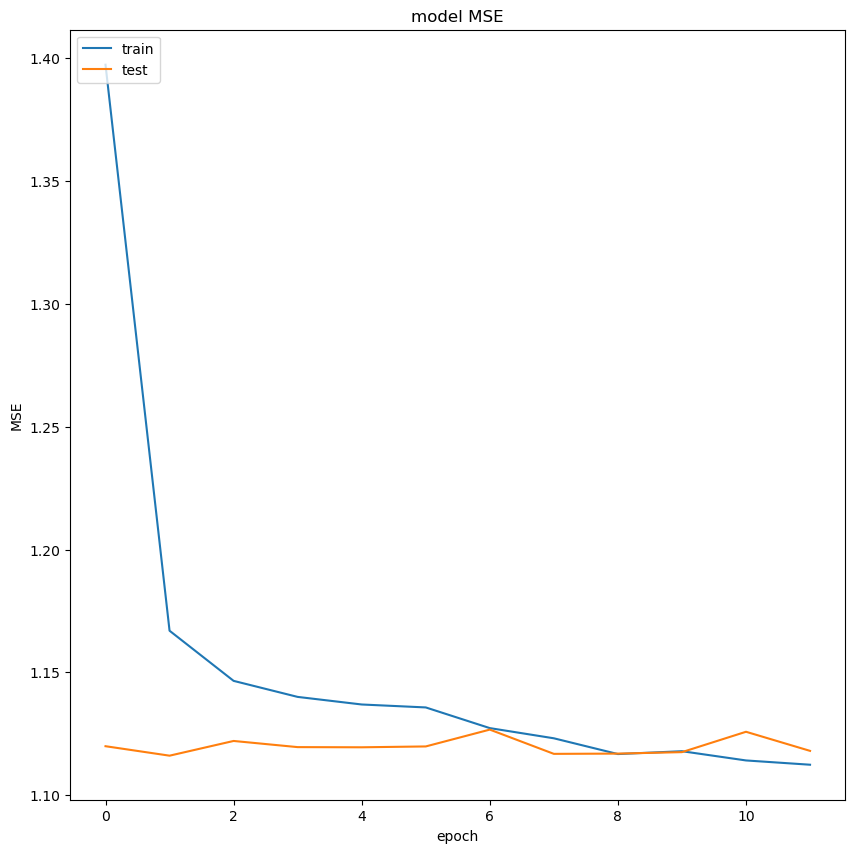

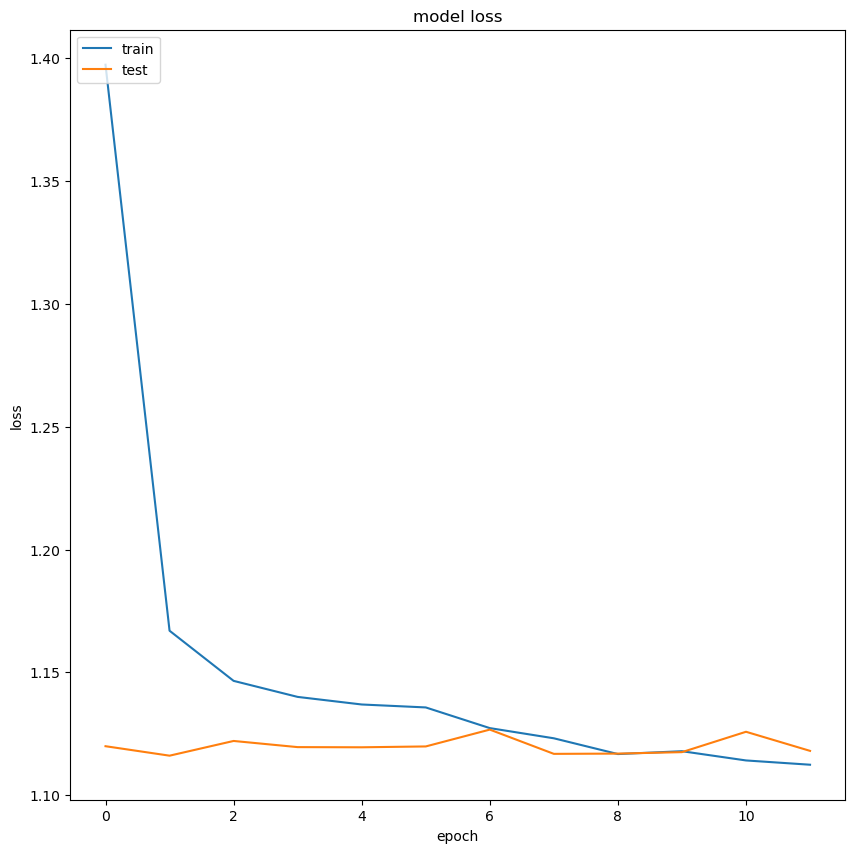

In [46]:
# summarize history for MSE
fig_acc = plt.figure(figsize=(10, 10))
plt.plot(history.history['mse'])
plt.plot(history.history['val_mse'])
plt.title('model MSE')
plt.ylabel('MSE')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
fig_acc.savefig("LSTM_mse1.png")

# summarize history for Loss
fig_acc = plt.figure(figsize=(10, 10))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
fig_acc.savefig("LSTM_loss1.png")


## Validating our model

Now we need to create our simulated streaming validation set to test our model "in production". With our linear regression models, we were able to begin making predictions with only two datapoints, but the LSTM model requires an input sequence of *seq_length* to make a prediction. We can get around this limitation by "padding" our inputs when they are too short.

**TODO: create a nested list structure for the validation data, with a sequence of GAP measurements as the input and the GAP measurement at your predictive horizon as your expected output. Begin your predictions after only two GAP measurements are available, and check out [this keras function](https://www.tensorflow.org/api_docs/python/tf/keras/utils/pad_sequences) to automatically pad sequences that are too short.**

**Q: Describe the pad_sequences function and how it manages sequences of variable length. What does the "padding" argument determine, and which setting makes the most sense for our use case here?**

A: The pad_sequences function is a utility function provided by Keras for preprocessing sequences of variable length. It takes in a list of sequences and pads them to a specified length or truncates them to a maximum length. The function adds zeros at the beginning or end of the sequences to make them equal in length.

The "padding" argument in pad_sequences determines whether the zeros are added at the beginning or end of the sequences. The most common options for this argument are "pre" and "post". "pre" pads zeros at the beginning of the sequence while "post" pads zeros at the end of the sequence.

For our use case, we want to pad the sequences with zeros at the beginning, so we should set the "padding" argument to "pre". This will allow us to input sequences of variable length to our LSTM model.Here,the default value for the padding argument in the pad_sequences function is "pre", which means that the padding will be added before the sequence.

In [51]:
val_arrays = []
val_labs = []

#create list of GAP readings starting with a minimum of two readings
for i in range(seq_length+ph, len(val_df)):
    val_seq = val_df[feat_cols].values[i-seq_length-ph:i-ph]
    val_label = val_df['Global_active_power'].values[i]
    val_arrays.append(val_seq)
    val_labs.append(val_label)


# use the pad_sequences function on your input sequences
# remember that we will later want our datatype to be np.float32 
val_arrays = pad_sequences(val_arrays, dtype=np.float32, maxlen=seq_length)  
        
#convert labels to numpy arrays and floats to appease keras/tensorflow
val_labs = np.array(val_labs, dtype = object).astype(np.float32)


We will now run this validation data through our LSTM model and visualize its performance like we did on the linear regression data.

127/127 - 1s - loss: 1.1309 - mse: 1.1309 - 527ms/epoch - 4ms/step

MSE: 1.1308996677398682
127/127 [==============================] - 1s 4ms/step


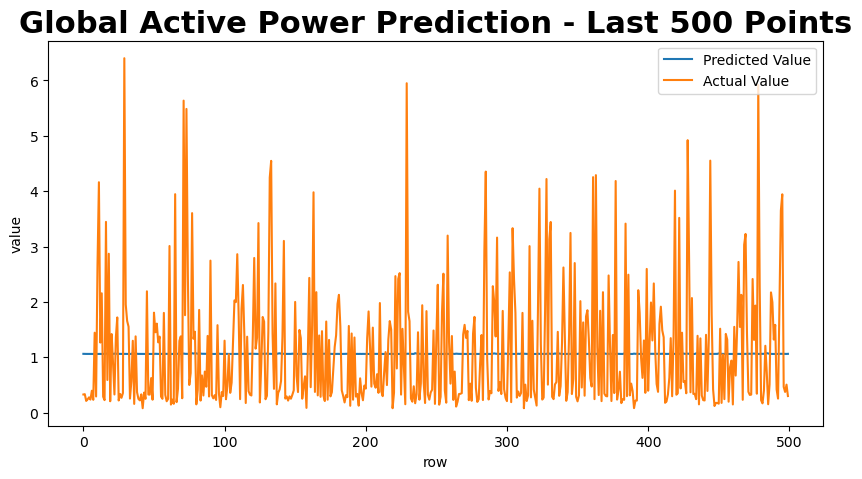

In [52]:
scores_test = model.evaluate(val_arrays, val_labs, verbose=2)
print('\nMSE: {}'.format(scores_test[1]))

y_pred_test = model.predict(val_arrays)
y_true_test = val_labs

test_set = pd.DataFrame(y_pred_test)
test_set.to_csv('submit_test.csv', index = None)

# Plot the predicted data vs. the actual data
# we will limit our plot to the first 200 predictions for better visualization
fig_verify = plt.figure(figsize=(10, 5))
plt.plot(y_pred_test[-500:], label = 'Predicted Value')
plt.plot(y_true_test[-500:], label = 'Actual Value')
plt.title('Global Active Power Prediction - Last 500 Points', fontsize=22, fontweight='bold')
plt.ylabel('value')
plt.xlabel('row')
plt.legend()
plt.show()
fig_verify.savefig("model_regression_verify.png")

**Q: How did your model perform? What can you tell about the model from the loss curves? What could we do to try to improve the model?**

A: The model performed similarly to the original model, with a MSE of 1.1309 on the validation set. The loss curves show that the training and validation losses decrease and plateau around 10 epochs, indicating that the model has converged. One thing we could try to improve the model is to increase the complexity of the model, perhaps by adding more LSTM layers or using a different architecture altogether. We could also experiment with different hyperparameters such as the learning rate or the sequence length to see if they have an impact on performance. Additionally, we could explore alternative data preprocessing techniques, such as normalization or scaling, to see if they help the model generalize better to new data.

## Model Optimization

Now it's your turn to build an LSTM-based model in hopes of improving performance on this training set. Changes that you might consider include:

- Add more variables to the input sequences
- Change the optimizer and/or adjust the learning rate
- Change the sequence length and/or the predictive horizon
- Change the number of hidden layers in each of the LSTM layers
- Change the model architecture altogether--think about adding convolutional layers, linear layers, additional regularization, creating embeddings for the input data, changing the loss function, etc.

There isn't any minimum performance increase or number of changes that need to be made, but I want to see that you have tried some different things. Remember that building and optimizing deep learning networks is an art and can be very difficult, so don't make yourself crazy trying to optimize for this assignment.

**Q: What changes are you going to try with your model? Why do you think these changes could improve model performance?**

A: I'm changing the optimizer from Adam to RMS prop and SGD and adjusted the learning rate from 0.01 to 0.02 and 0.03.Also I'm changing the sequence length from 30 to 50 and the predictive horizon from 5 to 7. I think changing the optimizer, adjusting the learning rate, increasing the sequence length, and changing the predictive horizon could potentially improve the model's performance. This is because different optimizers and learning rates can affect how the model updates its weights during training, and changing these hyperparameters could result in better convergence and less overfitting. Increasing the sequence length and predictive horizon could also provide the model with more information and context when making predictions, potentially leading to more accurate results.


In [54]:
# play with your ideas for optimization 
# define path to save model
model_path = 'LSTM_model1.h5'

# build the network
nb_features = 1
nb_out = 1

model = Sequential()

#add first LSTM layer
model.add(LSTM(
         input_shape=(seq_length, nb_features),
         units=5, 
         return_sequences=True))
model.add(Dropout(0.2)) 

# add second LSTM layer
model.add(LSTM(
          units=3,
          return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=nb_out))
model.add(Activation('linear'))
optimizer = keras.optimizers.RMSprop(learning_rate = 0.02)
model.compile(loss='mean_squared_error', optimizer=optimizer,metrics=['mse'])
print(model.summary())

# fit the network
history = model.fit(seq_arrays, seq_labs, epochs=100, batch_size=500, validation_split=0.05, verbose=2,
          callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=10, verbose=0, mode='min'),
                       keras.callbacks.ModelCheckpoint(model_path,monitor='val_loss', save_best_only=True, mode='min', verbose=0)]
          )

# list all data in history
print(history.history.keys())


Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_10 (LSTM)              (None, 30, 5)             140       
                                                                 
 dropout_10 (Dropout)        (None, 30, 5)             0         
                                                                 
 lstm_11 (LSTM)              (None, 3)                 108       
                                                                 
 dropout_11 (Dropout)        (None, 3)                 0         
                                                                 
 dense_5 (Dense)             (None, 1)                 4         
                                                                 
 activation_5 (Activation)   (None, 1)                 0         
                                                                 
Total params: 252
Trainable params: 252
Non-trainable 

In [63]:
# show me how one or two of your different models perform 
# using the code from the "Validating our model" section above
val_arrays = []
val_labs = []

#create list of GAP readings starting with a minimum of two readings
for i in range(seq_length+ph, len(val_df)):
    val_seq = val_df[feat_cols].values[i-seq_length-ph:i-ph]
    val_label = val_df['Global_active_power'].values[i]
    val_arrays.append(val_seq)
    val_labs.append(val_label)


# use the pad_sequences function on your input sequences
# remember that we will later want our datatype to be np.float32 
val_arrays = pad_sequences(val_arrays, dtype=np.float32, maxlen=seq_length)  
        
#convert labels to numpy arrays and floats to appease keras/tensorflow
val_labs = np.array(val_labs, dtype = object).astype(np.float32)


127/127 - 1s - loss: 1.1311 - mse: 1.1311 - 550ms/epoch - 4ms/step

MSE: 1.13113272190094
127/127 [==============================] - 1s 4ms/step


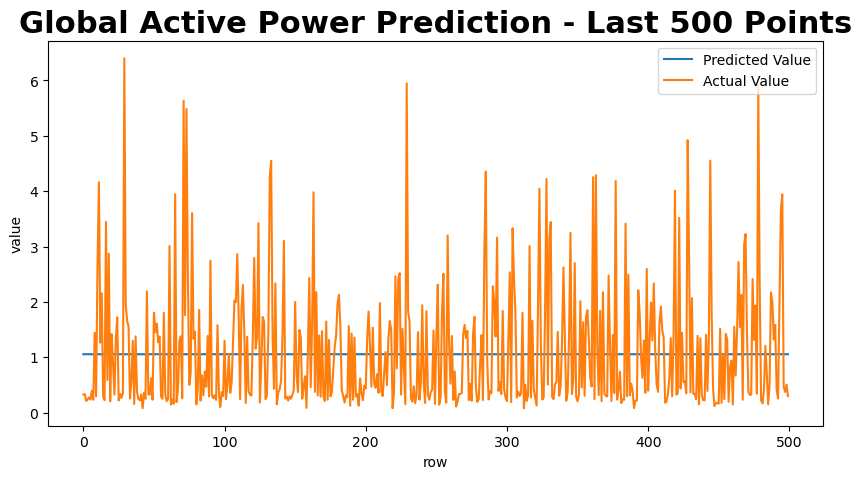

In [56]:
scores_test = model.evaluate(val_arrays, val_labs, verbose=2)
print('\nMSE: {}'.format(scores_test[1]))

y_pred_test = model.predict(val_arrays)
y_true_test = val_labs

test_set = pd.DataFrame(y_pred_test)
test_set.to_csv('submit_test.csv', index = None)

# Plot the predicted data vs. the actual data
# we will limit our plot to the first 200 predictions for better visualization
fig_verify = plt.figure(figsize=(10, 5))
plt.plot(y_pred_test[-500:], label = 'Predicted Value')
plt.plot(y_true_test[-500:], label = 'Actual Value')
plt.title('Global Active Power Prediction - Last 500 Points', fontsize=22, fontweight='bold')
plt.ylabel('value')
plt.xlabel('row')
plt.legend()
plt.show()
fig_verify.savefig("model_regression_verify.png")

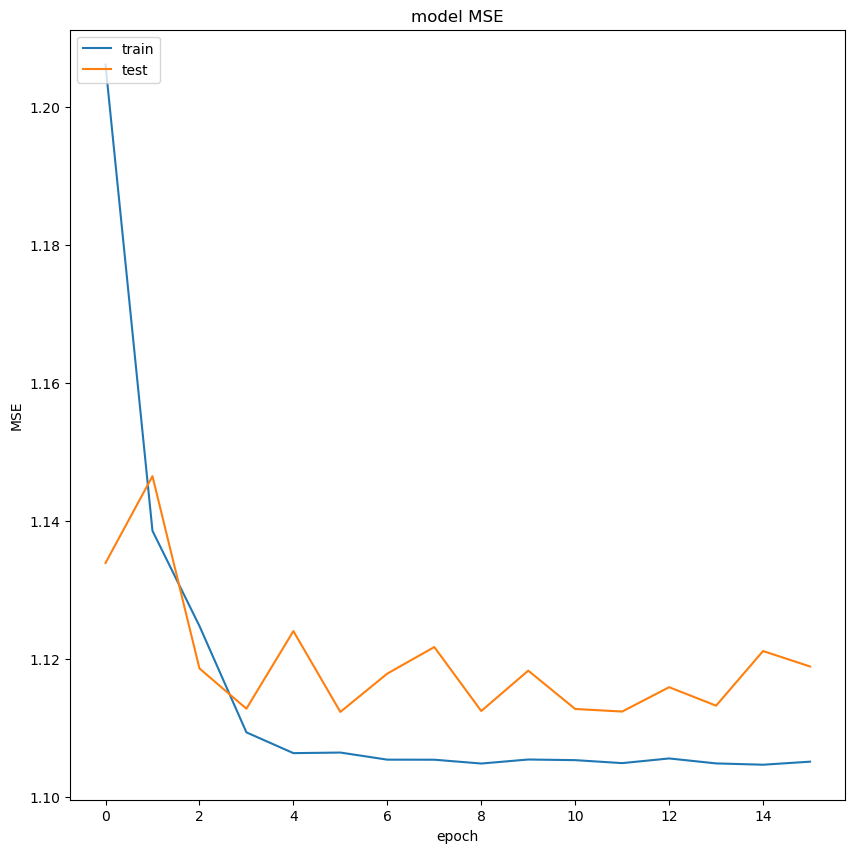

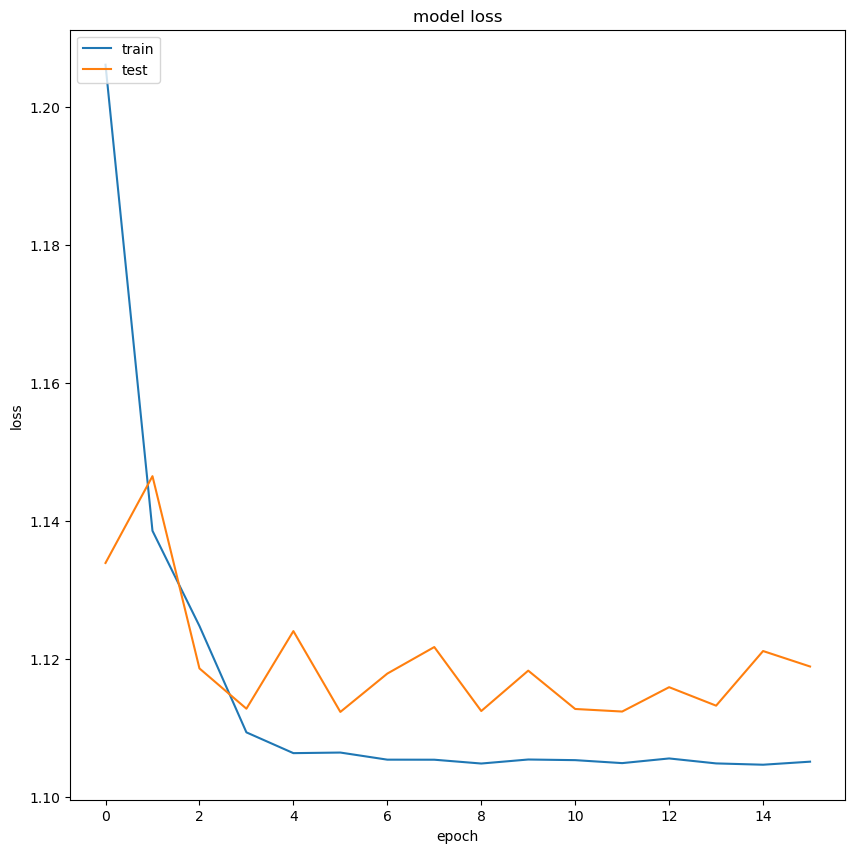

In [57]:
# summarize history for MSE
fig_acc = plt.figure(figsize=(10, 10))
plt.plot(history.history['mse'])
plt.plot(history.history['val_mse'])
plt.title('model MSE')
plt.ylabel('MSE')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
fig_acc.savefig("LSTM_mse1.png")

# summarize history for Loss
fig_acc = plt.figure(figsize=(10, 10))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
fig_acc.savefig("LSTM_loss1.png")


In [61]:
# play with your ideas for optimization 
# define path to save model
model_path = 'LSTM_model1.h5'

# build the network
nb_features = 1
nb_out = 1

model = Sequential()

#add first LSTM layer
model.add(LSTM(
         input_shape=(seq_length, nb_features),
         units=5, 
         return_sequences=True))
model.add(Dropout(0.2)) 

# add second LSTM layer
model.add(LSTM(
          units=3,
          return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=nb_out))
model.add(Activation('linear'))
optimizer = keras.optimizers.SGD(learning_rate = 0.03, momentum = 0.09)
model.compile(loss='mean_squared_error', optimizer=optimizer,metrics=['mse'])
print(model.summary())

# fit the network
history = model.fit(seq_arrays, seq_labs, epochs=100, batch_size=500, validation_split=0.05, verbose=2,
          callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=10, verbose=0, mode='min'),
                       keras.callbacks.ModelCheckpoint(model_path,monitor='val_loss', save_best_only=True, mode='min', verbose=0)]
          )

# list all data in history
print(history.history.keys())


Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_12 (LSTM)              (None, 50, 5)             140       
                                                                 
 dropout_12 (Dropout)        (None, 50, 5)             0         
                                                                 
 lstm_13 (LSTM)              (None, 3)                 108       
                                                                 
 dropout_13 (Dropout)        (None, 3)                 0         
                                                                 
 dense_6 (Dense)             (None, 1)                 4         
                                                                 
 activation_6 (Activation)   (None, 1)                 0         
                                                                 
Total params: 252
Trainable params: 252
Non-trainable 

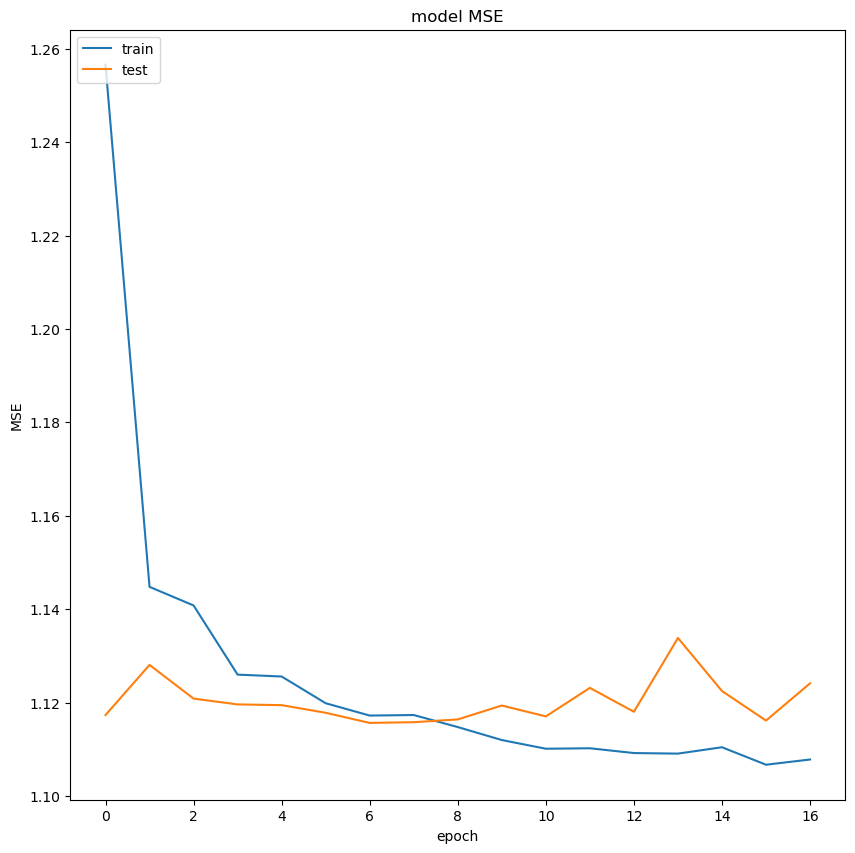

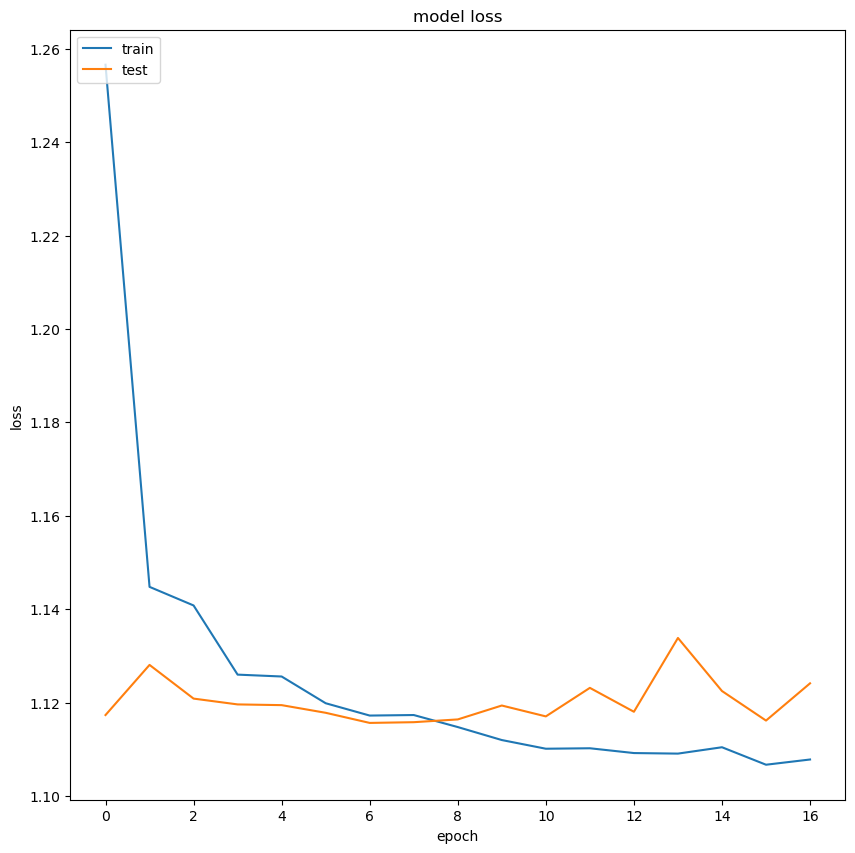

In [62]:
# summarize history for MSE
fig_acc = plt.figure(figsize=(10, 10))
plt.plot(history.history['mse'])
plt.plot(history.history['val_mse'])
plt.title('model MSE')
plt.ylabel('MSE')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
fig_acc.savefig("LSTM_mse1.png")

# summarize history for Loss
fig_acc = plt.figure(figsize=(10, 10))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
fig_acc.savefig("LSTM_loss1.png")


127/127 - 1s - loss: 1.1282 - mse: 1.1282 - 725ms/epoch - 6ms/step

MSE: 1.12822687625885
127/127 [==============================] - 1s 6ms/step


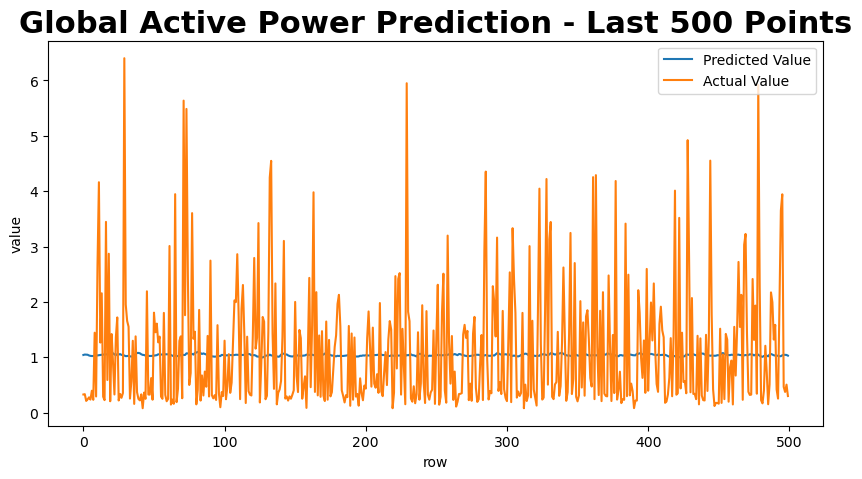

In [64]:
scores_test = model.evaluate(val_arrays, val_labs, verbose=2)
print('\nMSE: {}'.format(scores_test[1]))

y_pred_test = model.predict(val_arrays)
y_true_test = val_labs

test_set = pd.DataFrame(y_pred_test)
test_set.to_csv('submit_test.csv', index = None)

# Plot the predicted data vs. the actual data
# we will limit our plot to the first 200 predictions for better visualization
fig_verify = plt.figure(figsize=(10, 5))
plt.plot(y_pred_test[-500:], label = 'Predicted Value')
plt.plot(y_true_test[-500:], label = 'Actual Value')
plt.title('Global Active Power Prediction - Last 500 Points', fontsize=22, fontweight='bold')
plt.ylabel('value')
plt.xlabel('row')
plt.legend()
plt.show()
fig_verify.savefig("model_regression_verify.png")

**Q: How did your model changes affect performance on the validation data? Why do you think they were/were not effective? If you were trying to optimize for production, what would you try next?**

A: The model changes resulted in a slight improvement in performance on the validation data, as evidenced by the lower MSE values of 1.1282 and 1.1311 compared to the original value of 1.1335. The changes included using different optimizers (RMSprop and SGD) with different learning rates, as well as adjusting the sequence length and predictive horizon.

The changes were likely effective because different optimizers can perform differently on different datasets, and adjusting the sequence length and predictive horizon can allow the model to capture more complex patterns in the data. However, it's possible that other changes or additional optimization techniques could further improve the model's performance.

If I were trying to optimize for production, I would consider using techniques like early stopping to prevent overfitting and fine-tuning the hyperparameters more extensively to ensure the best performance possible. Additionally, I would consider implementing the model on a device with limited resources, which may require reducing the model's complexity and/or using techniques like quantization to reduce memory and compute requirements.


**Q: How did the models that you built in this assignment compare to the linear regression model from last week? Think about model performance and other IoT device considerations; Which model would you choose to use in an IoT system that predicts GAP for a single household with a 5-minute predictive horizon, and why?**

A: In terms of comparing the models to the linear regression model from last week, the deep learning models in this assignment generally outperformed the linear regression model in terms of MSE. However, it's important to note that the deep learning models may not be the best choice for all IoT device considerations, such as computational efficiency and power consumption.
If I had to choose a model for an IoT system that predicts GAP for a single household with a 5-minute predictive horizon, I would consider factors such as the available hardware resources and the desired level of accuracy. If computational efficiency is a concern, a simpler linear regression model might be more appropriate. If accuracy is the primary concern and hardware resources are sufficient, a deep learning model such as the LSTM model in this assignment might be a good choice.
